# SABR interpolation on cleaned historical data — unified-grid demo

Same **dataset** as in `docs/sabr_interpolation.md` (processed parquet from `data_pipeline.py` → `clean_data` → `processed.parquet`). Pick any **evaluation** grids `k_grid` and `tau_grid` for the dense surface; they do not need to match a kernel smoother.

Interpolation follows the repo SABR path: **per-expiry** `(α, ρ, ν)` with fixed `β`, then **`implied_vol_surface_from_calibrated_slices`** (Hagan lognormal `sabr_lognormal_iv` on each grid point), wired for historic quotes by **`build_historical_sabr_surface`** (`filter_day_for_surface`, expiry grouping, `m = exp(k)` for moneyness).

This notebook also demonstrates **pixel consistency** across historical, synthetic SABR and synthetic Heston sources via the shared `UnifiedGrid` (`config/unified_iv_grid.yaml`, `k ∈ [−0.5, 0.5]`, `τ ∈ [0.05, 2.0]`) and the per-pixel `SurfaceNormalizer` that maps every surface to a common `z`-score of `log σ`. See `docs/unified_grid_and_normalization.md`.

Run with `pip install -e .` from the repo root.

In [30]:
from pathlib import Path

import numpy as np
import pandas as pd

from implied_volatility_diffusion import (
    UnifiedGrid,
)
from implied_volatility_diffusion.data.historical_data_smoothing_interpolation import (
    load_cleaned_data,
    plot_smile,
    plot_surface_3d,
)
from implied_volatility_diffusion.data.historical_sabr_interpolation import (
    build_historical_sabr_surface,
)

## Load cleaned data

Default path matches `config/data_pipeline_config.yaml` (`processed_output_path`).

In [ ]:
cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd

processed_data_path = repo_root / "data" / "processed" / "processed.parquet"
df = load_cleaned_data(processed_data_path)

sample_date = pd.Timestamp("2021-06-17")
day = df[df["quote_date"] == sample_date].copy()
print("cleaned dataset:", processed_data_path)
print("sample_date:", sample_date, "rows (this day):", len(day))

r, q, beta = 0.03, 0.0, 0.5

## SABR dense surface on the **unified grid**

We use `UnifiedGrid.default()` — `k ∈ [−0.5, 0.5]`, `τ ∈ [0.05, 2.0]`, shape `(41, 40)` — so the historical SABR surface shares pixels with everything the synthetic SABR / Heston generators produce.

In [32]:
unified_grid = UnifiedGrid.load(repo_root / "config" / "unified_iv_grid.yaml")
k_grid = unified_grid.log_moneyness
tau_grid = unified_grid.tau
KGRID, TAUGRID = unified_grid.meshgrid()
print("unified grid:", unified_grid.shape, "k in", (k_grid[0], k_grid[-1]), "tau in", (tau_grid[0], tau_grid[-1]))

sabr_out = build_historical_sabr_surface(day, k_grid, tau_grid, r=r, q=q, beta=beta)
Z_sabr_hist = sabr_out.surface

print("historical SABR — rows:", len(sabr_out.day_sub), "surface shape:", Z_sabr_hist.shape)
print("finite:", np.isfinite(Z_sabr_hist).sum(), "/", Z_sabr_hist.size, "spot:", sabr_out.spot)
print("(alpha, rho, nu) per expiry:\n", sabr_out.calibrated_params)

unified grid: (41, 40) k in (np.float64(-0.5), np.float64(0.5000000000000003)) tau in (np.float64(0.05), np.float64(2.000000000000001))
historical SABR — rows: 12812 surface shape: (41, 40)
finite: 1640 / 1640 spot: 4221.88
(alpha, rho, nu) per expiry:
 [[ 3.60780767 -0.46402666 12.1418079 ]
 [ 4.82171732 -0.53363283  9.5501019 ]
 [ 6.10293073 -0.51142184  7.41873753]
 [ 6.05210469 -0.52693137  6.19152321]
 [ 6.63298143 -0.29733808  5.54805986]
 [ 5.61716971 -0.16981528  5.96876314]
 [ 6.36746339 -0.48735924  5.00612725]
 [ 6.47423226 -0.55973258  4.91816148]
 [ 6.91433853 -0.61023275  4.50531858]
 [ 6.90983342 -0.62824667  4.22174732]
 [ 7.10772944 -0.62981855  4.05764949]
 [ 6.8796608  -0.68991918  4.24476715]
 [ 7.18743742 -0.71327162  3.9628418 ]
 [ 7.37266126 -0.69954729  3.66710199]
 [ 7.50781592 -0.70468754  3.45400885]
 [ 7.93650618 -0.7009428   3.07727881]
 [ 8.37232554 -0.66556307  2.4000613 ]
 [ 8.74225664 -0.67710407  2.20915421]
 [ 9.18053338 -0.67902545  1.88104591]
 [ 9.

## Plots

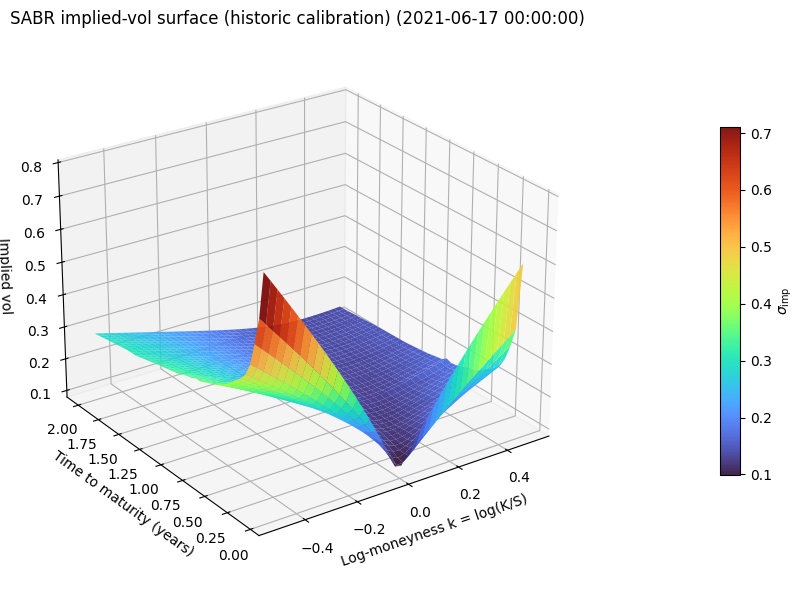

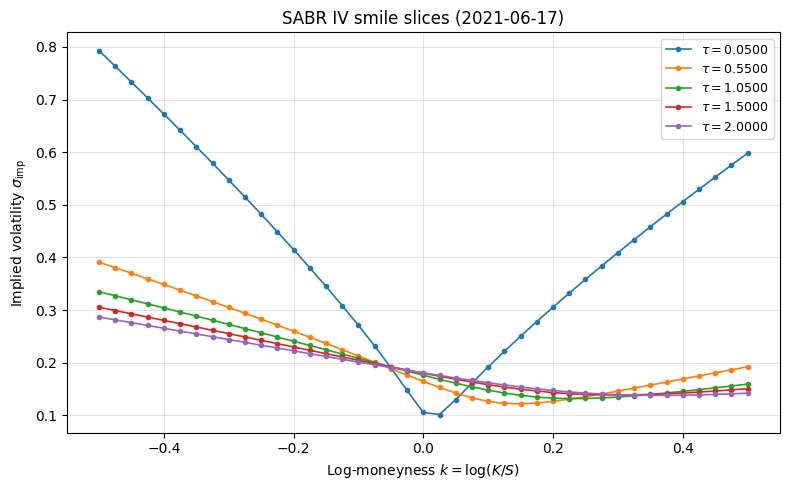

In [33]:
plot_surface_3d(
    KGRID,
    TAUGRID,
    Z_sabr_hist,
    sample_date,
    title="SABR implied-vol surface (historic calibration)",
)

plot_smile(
    k_grid,
    tau_grid,
    Z_sabr_hist,
    sample_date,
    title="SABR IV smile slices",
)